# VQ-VAE Codebook Check

In [1]:
import os, sys, yaml, math
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = '/home/irteam/local-node-d/hbkimi/ecg-fm'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

CKPT_DIR = 'checkpoints/tokenizer_heedb_full_cb128_v4'
LOG_DIR  = 'logs/tokenizer_heedb_full_cb128_v4'
CFG_PATH = 'configs/tokenizer/vqvae_heedb_full_cb128_v4.yaml'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

# # 128
# CKPT_DIR = 'checkpoints/tokenizer_heedb_full_cb128_v4'
# LOG_DIR  = 'logs/tokenizer_heedb_full_cb128_v4'
# CFG_PATH = 'configs/tokenizer/vqvae_heedb_full_cb128_v4.yaml'

# # 256
# CKPT_DIR = 'checkpoints/tokenizer_heedb_full_cb256_v4'
# LOG_DIR  = 'logs/tokenizer_heedb_full_cb256_v4'
# CFG_PATH = 'configs/tokenizer/vqvae_heedb_full_cb256_v4.yaml'

# # 512
# CKPT_DIR = 'checkpoints/tokenizer_heedb_full_cb512_v4'
# LOG_DIR  = 'logs/tokenizer_heedb_full_cb512_v4'
# CFG_PATH = 'configs/tokenizer/vqvae_heedb_full_cb512_v4.yaml'

# # 1024
# CKPT_DIR = 'checkpoints/tokenizer_heedb_full_cb1024_v4'
# LOG_DIR  = 'logs/tokenizer_heedb_full_cb1024_v4'
# CFG_PATH = 'configs/tokenizer/vqvae_heedb_full_cb1024_v4.yaml'

# # 2048
# CKPT_DIR = 'checkpoints/tokenizer_heedb_full_cb2048_v4'
# LOG_DIR  = 'logs/tokenizer_heedb_full_cb2048_v4'
# CFG_PATH = 'configs/tokenizer/vqvae_heedb_full_cb2048_v4.yaml'

device: cuda


## 1. Training curves

In [2]:
df = pd.read_csv(os.path.join(LOG_DIR, 'metrics.csv'))
print(df.shape, '\nsplits:', df['split'].unique())
df.head()

(306922, 11) 
splits: ['train' 'val']


,split,epoch,elapsed,loss,loss_rec,loss_vq,loss_fid,loss_spec,loss_ent,perplexity,n_dead_restarted
0,train,1,22.8,14.710247,2.736869,0.001064,5.604734,6.646722,-4.683250,7.142432,0.0
1,train,1,23.7,15.248638,2.865827,0.000327,5.763412,6.720647,-3.048746,7.311233,0.0
2,train,1,23.7,15.092758,2.854720,0.000298,5.696296,6.688634,-3.162959,8.861057,0.0
3,train,1,23.7,15.097753,2.827048,0.000285,5.707334,6.729089,-3.072231,8.773071,0.0
4,train,1,23.7,15.191942,2.904992,0.000340,5.714259,6.737360,-3.050241,8.385437,0.0


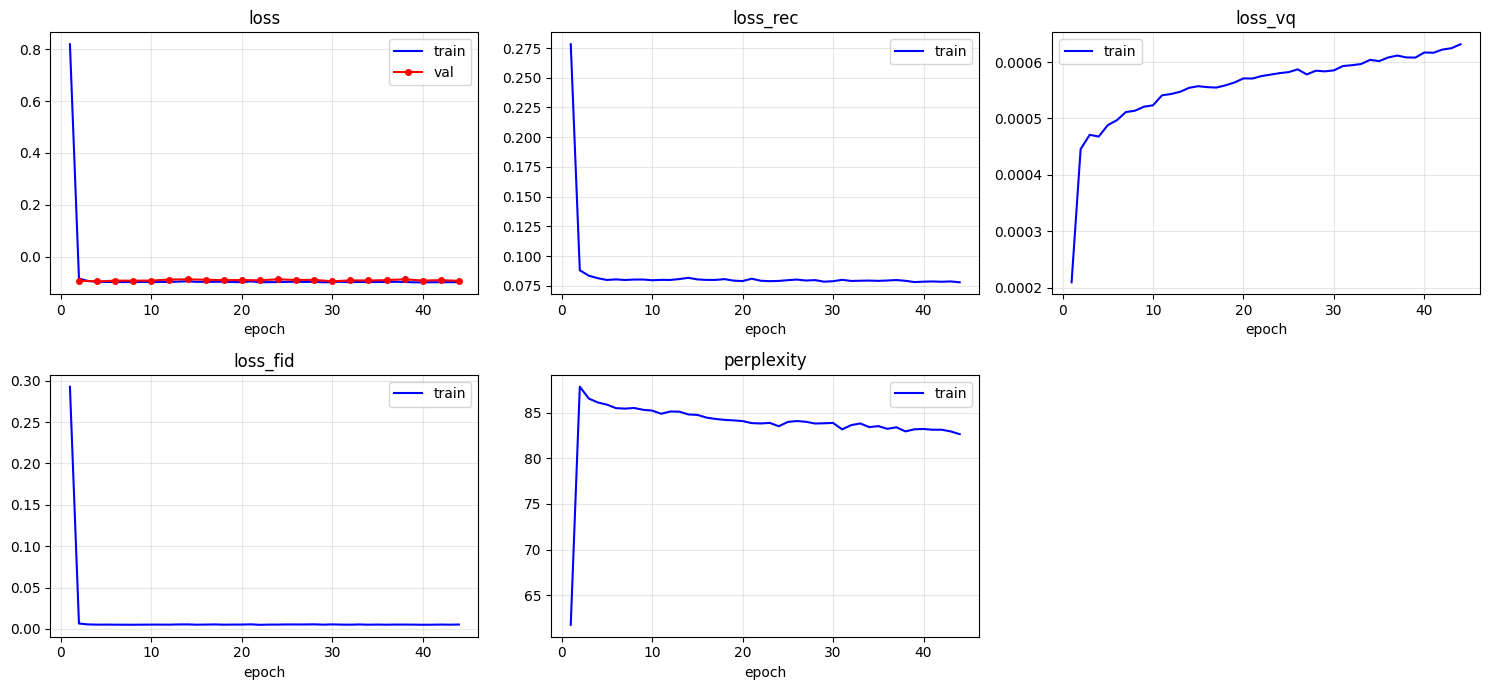

best val_loss : -0.0958714634180069
final ppl     : 82.65816719807177 (codebook K=256, usage≈16.1%)


In [3]:
train = df[df['split'] == 'train']
val   = df[df['split'] == 'val']

# epoch별 train 평균
train_ep = train.groupby('epoch').agg({
    'loss': 'mean', 'loss_rec': 'mean', 'loss_vq': 'mean',
    'loss_fid': 'mean', 'perplexity': 'mean'
}).reset_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flat, ['loss','loss_rec','loss_vq','loss_fid','perplexity']):
    ax.plot(train_ep['epoch'], train_ep[col], 'b-', label='train')
    if col == 'loss' and not val.empty:
        ax.plot(val['epoch'], val['loss'], 'r-o', label='val', ms=4)
    ax.set_title(col); ax.set_xlabel('epoch'); ax.legend(); ax.grid(alpha=0.3)
axes.flat[-1].axis('off')
plt.tight_layout(); plt.show()

print('best val_loss :', val['loss'].min() if not val.empty else 'n/a')
print('final ppl     :', train_ep['perplexity'].iloc[-1], f"(codebook K=256, usage≈{train_ep['perplexity'].iloc[-1]/512:.1%})")

## 2. Load best checkpoint

In [4]:
from models.tokenizer.vqvae import VQVAE

with open(CFG_PATH) as f:
    cfg = yaml.safe_load(f)

ckpt = torch.load(os.path.join(CKPT_DIR, 'last.pt'), map_location=DEVICE)
model_cfg = ckpt.get('model_cfg') or cfg['model']
model = VQVAE(model_cfg).to(DEVICE)
model.load_state_dict(ckpt['model'])
model.eval()
print('epoch =', ckpt.get('epoch'), ' metric =', ckpt.get('metric'))
print('params:', sum(p.numel() for p in model.parameters()))

epoch = 44  metric = -0.09444969892501831
params: 1439682


## 3. Validation beats → reconstruction

In [5]:
from data.datasets.heedb_beat_dataset import HEEDBBeatDataset
from torch.utils.data import DataLoader

data_cfg = dict(cfg['data']); data_cfg['max_beats_per_record'] = 4
val_ds = HEEDBBeatDataset(data_cfg, split='val')
val_loader = DataLoader(val_ds, batch_size=256, num_workers=4, shuffle=False)

# 첫 배치만 사용해 빠르게 확인
batch = next(iter(val_loader))
x = batch['beat'].to(DEVICE)
with torch.no_grad():
    x_hat, vq = model(x)

mse = ((x - x_hat) ** 2).mean(dim=(1,2))
print('batch shape:', x.shape)
print('mean MSE:', mse.mean().item(), '  median:', mse.median().item())
print('batch perplexity:', vq['perplexity'].item())

[HEEDBBeatDataset:val] 10,000 records  record_cache_cap=8000
batch shape: torch.Size([256, 1, 256])
mean MSE: 0.06986179947853088   median: 0.028780145570635796
batch perplexity: 46.372676849365234


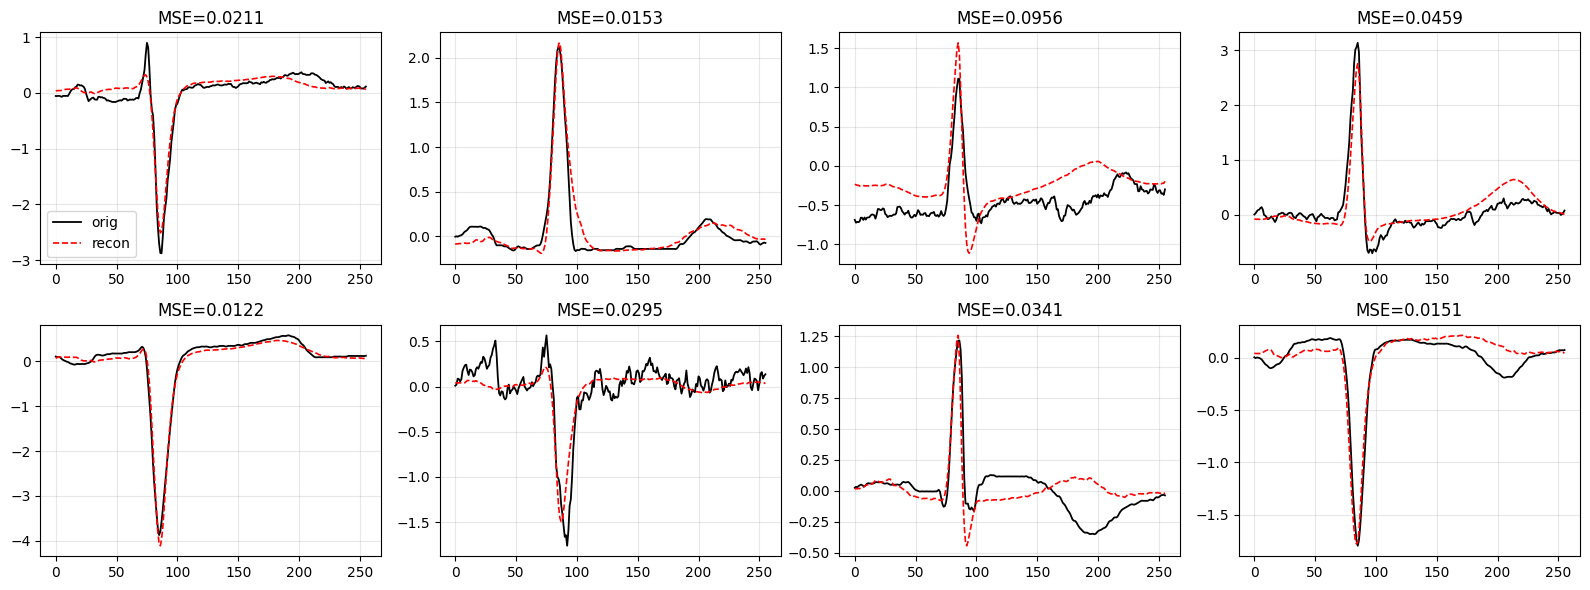

In [8]:
# 재구성 시각화 (8개 비트)
n = 8
idx = torch.randperm(x.size(0))[:n]
x_n = x[idx].cpu().numpy()[:,0,:]
xh_n = x_hat[idx].cpu().numpy()[:,0,:]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(x_n[i], 'k-', lw=1.3, label='orig')
    ax.plot(xh_n[i], 'r--', lw=1.2, label='recon')
    ax.set_title(f'MSE={((x_n[i]-xh_n[i])**2).mean():.4f}')
    ax.grid(alpha=0.3)
    if i == 0: ax.legend()
plt.tight_layout(); plt.show()

## 4. Codebook usage / dead codes

In [9]:
K = model.codebook.K
counts = torch.zeros(K, dtype=torch.long)
total = 0
MAX_BATCHES = 40   # 더 정밀하게 보려면 늘릴 것

with torch.no_grad():
    for i, b in enumerate(val_loader):
        if i >= MAX_BATCHES: break
        xb = b['beat'].to(DEVICE)
        _, vq = model(xb)
        idx = vq['indices'].cpu()
        counts += torch.bincount(idx, minlength=K)
        total += idx.numel()

probs = counts.float() / total
nonzero = (counts > 0).sum().item()
dead = K - nonzero
ppl = torch.exp(-(probs[probs>0] * probs[probs>0].log()).sum()).item()
print(f'samples scanned : {total:,}')
print(f'codebook K      : {K}')
print(f'active codes    : {nonzero} ({nonzero/K:.1%})')
print(f'dead codes      : {dead}')
print(f'perplexity      : {ppl:.1f}  (max={K})')
print(f'top-10 usage    : {probs.topk(10).values.sum().item():.2%}')

samples scanned : 10,240
codebook K      : 128
active codes    : 127 (99.2%)
dead codes      : 1
perplexity      : 119.4  (max=128)
top-10 usage    : 12.60%


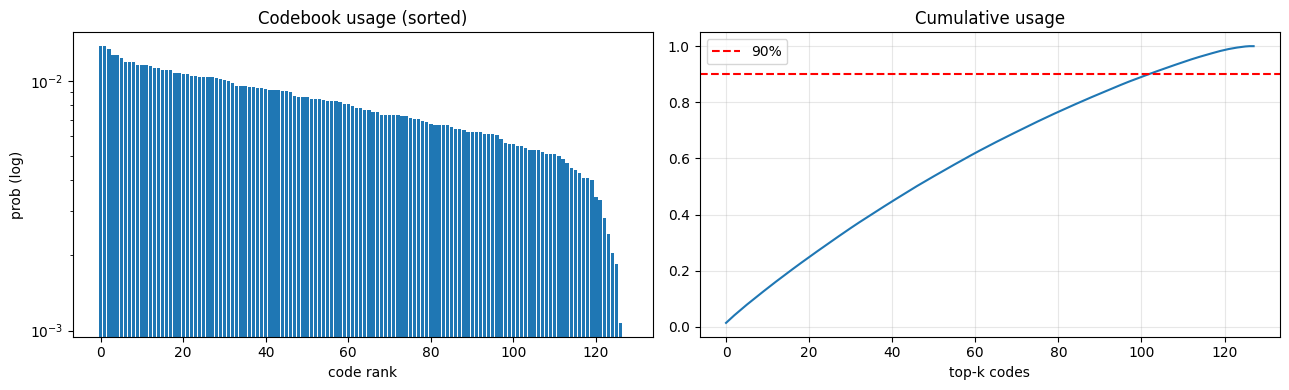

90% of usage covered by top-103 codes (80.5% of codebook)


In [10]:
sorted_probs = probs.sort(descending=True).values.numpy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(K), sorted_probs); axes[0].set_yscale('log')
axes[0].set_title('Codebook usage (sorted)'); axes[0].set_xlabel('code rank'); axes[0].set_ylabel('prob (log)')
cum = np.cumsum(sorted_probs)
axes[1].plot(cum); axes[1].axhline(0.9, color='r', ls='--', label='90%')
axes[1].set_title('Cumulative usage'); axes[1].set_xlabel('top-k codes'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

k90 = int((cum < 0.9).sum()) + 1
print(f'90% of usage covered by top-{k90} codes ({k90/K:.1%} of codebook)')

## 5. Codebook embedding geometry (optional)

embedding shape: (128, 256)
norm  mean/std : 1.0000086 2.6185671e-05
norm  min /max : 0.99992865 1.0000948


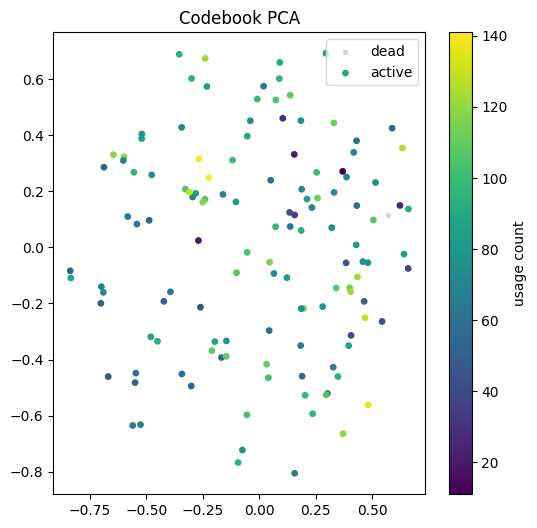

In [11]:
W = model.codebook.embedding.weight.detach().cpu().numpy()
norms = np.linalg.norm(W, axis=1)
print('embedding shape:', W.shape)
print('norm  mean/std :', norms.mean(), norms.std())
print('norm  min /max :', norms.min(), norms.max())

try:
    from sklearn.decomposition import PCA
    P = PCA(n_components=2).fit_transform(W)
    active = (counts > 0).numpy()
    plt.figure(figsize=(6,6))
    plt.scatter(P[~active,0], P[~active,1], c='lightgray', s=8, label='dead')
    sc = plt.scatter(P[active,0], P[active,1], c=counts[active].numpy(), s=15, cmap='viridis', label='active')
    plt.colorbar(sc, label='usage count'); plt.legend(); plt.title('Codebook PCA')
    plt.show()
except Exception as e:
    print('PCA skipped:', e)

## 6. Top-k code decoding

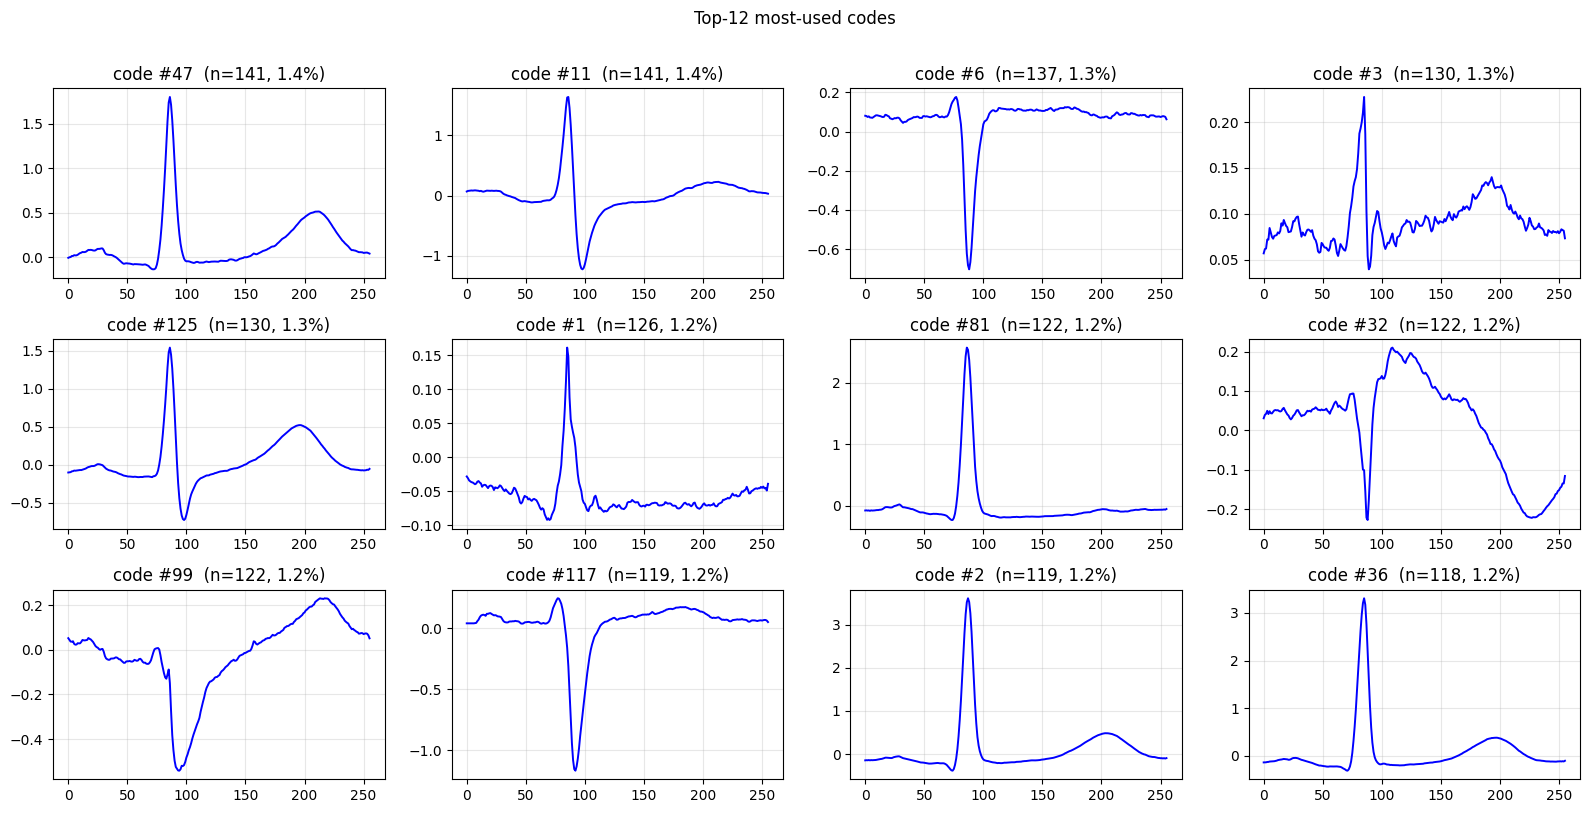

In [12]:
topk = 12
top_idx = counts.topk(topk).indices.to(DEVICE)
top_cnt = counts.topk(topk).values.tolist()

with torch.no_grad():
    # codebook.embedding(idx) -> (topk, D) -> decoder 입력 (B, D)
    z_q = model.codebook.embedding(top_idx)          # (topk, D)
    decoded = model.decoder(z_q).cpu().numpy()        # (topk, 1, W)

fig, axes = plt.subplots(3, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(decoded[i, 0], 'b-', lw=1.4)
    ax.set_title(f'code #{top_idx[i].item()}  (n={top_cnt[i]}, {top_cnt[i]/total:.1%})')
    ax.grid(alpha=0.3)
plt.suptitle(f'Top-{topk} most-used codes', y=1.01)
plt.tight_layout(); plt.show()

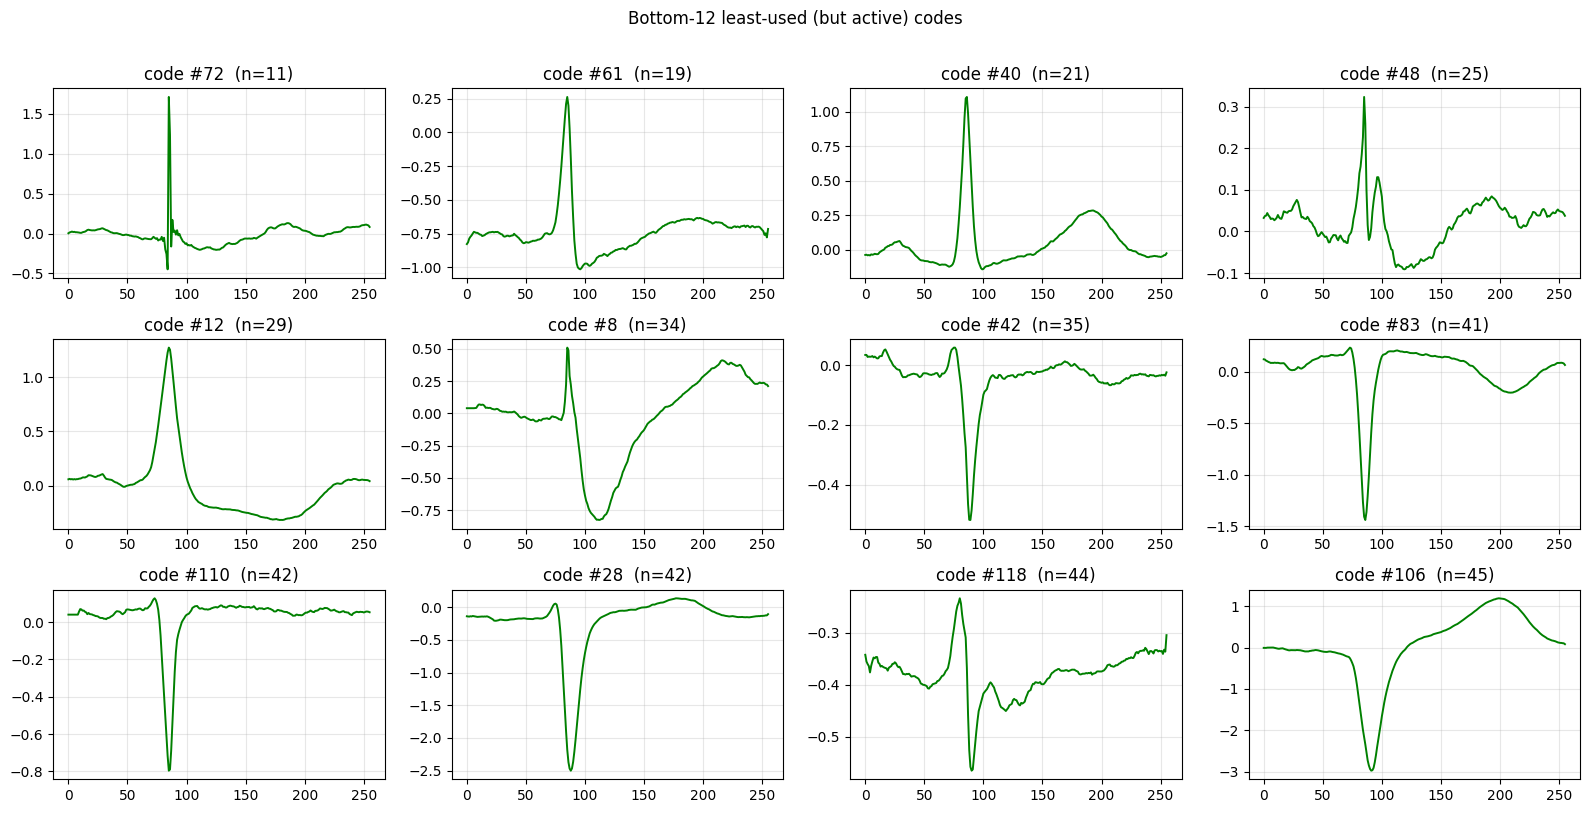

In [13]:
# 대조군: 사용 빈도 하위(active 중) 코드
active_counts = counts.clone()
active_counts[counts == 0] = 10**9  # dead 있으면 제외 — 현재 0개지만 방어
bot_idx = active_counts.topk(topk, largest=False).indices.to(DEVICE)
bot_cnt = counts[bot_idx.cpu()].tolist()

with torch.no_grad():
    z_q_b = model.codebook.embedding(bot_idx)
    dec_b = model.decoder(z_q_b).cpu().numpy()

fig, axes = plt.subplots(3, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.plot(dec_b[i, 0], 'g-', lw=1.4)
    ax.set_title(f'code #{bot_idx[i].item()}  (n={bot_cnt[i]})')
    ax.grid(alpha=0.3)
plt.suptitle(f'Bottom-{topk} least-used (but active) codes', y=1.01)
plt.tight_layout(); plt.show()

## 7. codebook per lead

In [14]:
# 리드 차원을 유지한 채 비트 추출 — dataset 내부 로직을 그대로 재현
from data.preprocessing.heedb_io       import load_heedb_record, align_to_heedb_order, HEEDB_LEAD_ORDER
from data.preprocessing.beat_segmentor import detect_rpeaks, extract_beats, LEAD_II_INDEX
from data.preprocessing.resampler      import resample_signal, resample_beat, normalize_beat

LEADS = HEEDB_LEAD_ORDER  # 길이 12
print('lead order:', LEADS)

def beats_per_lead(path, cfg):
    '''한 레코드 → (N, 12, W) 정규화 beats'''
    rec = load_heedb_record(path, load_rpeaks=True)
    if rec is None: return None
    sig = align_to_heedb_order(rec['signal'], rec['sig_name'])
    if sig is None: return None
    fs_in = rec['fs']; fs = int(cfg.get('target_fs', 500))
    rpk = rec['rpeaks']
    if fs_in != fs:
        sig = resample_signal(sig, fs_in, fs)
        if rpk is not None:
            rpk = (rpk.astype(np.float64) * fs / fs_in).astype(np.int64)
    if rpk is None or len(rpk) < 2:
        try: rpk = detect_rpeaks(sig[LEAD_II_INDEX], fs, method='neurokit')
        except Exception: return None
    if len(rpk) < 2: return None
    beats = extract_beats(sig, rpk, fs,
                          before_ms=int(cfg.get('before_ms',200)),
                          after_ms=int(cfg.get('after_ms',400)))
    if len(beats) == 0: return None
    beats = np.stack(beats, axis=0)           # (N, 12, W_raw)
    N, L, W = beats.shape
    flat = beats.reshape(N*L, W)
    flat = resample_beat(flat, int(cfg.get('beat_length',256)))
    flat = normalize_beat(flat, cfg.get('normalize','zscore'))   # (N*L, beat_len)
    return flat.reshape(N, L, -1).astype(np.float32)

# val 파일 리스트에서 샘플링해서 인덱스 수집
with open(cfg['data']['val_list']) as f:
    val_files = [ln.strip() for ln in f if ln.strip()]
print(f'val files: {len(val_files):,}')

lead order: ['I', 'II', 'III', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'aVF', 'aVL', 'aVR']
val files: 10,000


In [17]:
import random, time
random.seed(0)
N_RECORDS = 400
K = model.codebook.K
NUM_LEADS = 12
lead_counts = torch.zeros(NUM_LEADS, K, dtype=torch.long)
t0 = time.time(); ok = 0

for i, fp in enumerate(random.sample(val_files, N_RECORDS)):
    arr = beats_per_lead(fp, cfg['data'])
    if arr is None or arr.shape[0] == 0:
        continue
    N, L, W = arr.shape
    x = torch.from_numpy(arr).to(DEVICE).reshape(N*L, 1, W)
    with torch.no_grad():
        z_e = model.encoder(x)
        _, idx, *_ = model.codebook(z_e)
    idx = idx.view(N, L).cpu()
    for li in range(L):
        lead_counts[li] += torch.bincount(idx[:, li], minlength=K)
    ok += 1

print(f'records used: {ok}/{N_RECORDS}   elapsed={time.time()-t0:.1f}s')
print(f'beats/lead : {lead_counts.sum(1).tolist()}')

records used: 400/400   elapsed=26.4s
beats/lead : [4533, 4533, 4533, 4533, 4533, 4533, 4533, 4533, 4533, 4533, 4533, 4533]


In [18]:
# 리드별 지표: active, perplexity
rows = []
for li, name in enumerate(LEADS):
    c = lead_counts[li].float()
    tot = c.sum().item()
    p = c / max(tot, 1)
    active = (c > 0).sum().item()
    nz = p[p > 0]
    ppl_l = float(torch.exp(-(nz * nz.log()).sum())) if nz.numel() else 0.0
    rows.append((name, int(tot), active, ppl_l))
pd.DataFrame(rows, columns=['lead','n_beats','active_codes','perplexity']).set_index('lead')

,n_beats,active_codes,perplexity
lead,,,
I,4533,74,21.962500
II,4533,73,28.917780
III,4533,84,29.054533
V1,4533,69,21.258833
V2,4533,85,37.222683
V3,4533,92,41.073875
V4,4533,91,41.379524
V5,4533,87,35.605835
V6,4533,80,29.239485


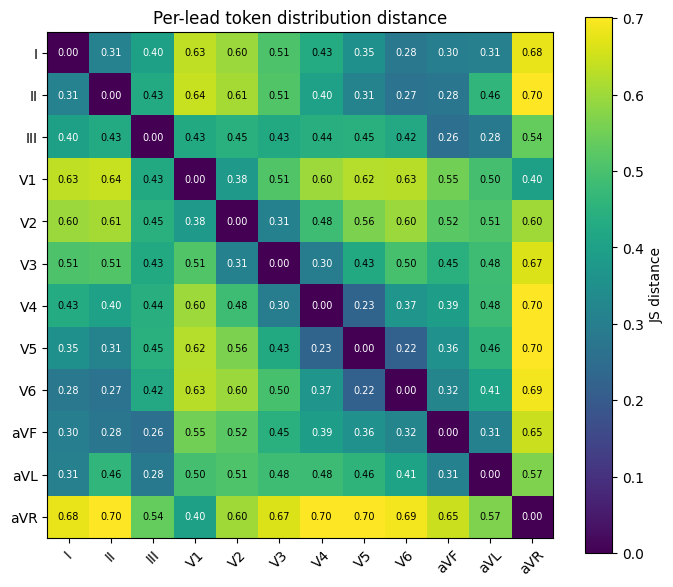


Distance from Lead II (sorted):
    V6  0.268
   aVF  0.276
     I  0.312
    V5  0.314
    V4  0.402
   III  0.430
   aVL  0.461
    V3  0.513
    V2  0.609
    V1  0.644
   aVR  0.702


In [19]:
# 리드별 분포 유사도: Jensen-Shannon distance matrix
eps = 1e-12
P = lead_counts.float()
P = P / P.sum(1, keepdim=True).clamp(min=1)      # (12, K)

def js_div(p, q):
    m = 0.5 * (p + q)
    def kl(a, b): return (a * (a.clamp(min=eps).log() - b.clamp(min=eps).log())).sum(-1)
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

JS = torch.zeros(NUM_LEADS, NUM_LEADS)
for i in range(NUM_LEADS):
    for j in range(NUM_LEADS):
        JS[i, j] = js_div(P[i], P[j]).sqrt()     # JS distance in [0,1]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(JS.numpy(), cmap='viridis', vmin=0)
ax.set_xticks(range(NUM_LEADS)); ax.set_yticks(range(NUM_LEADS))
ax.set_xticklabels(LEADS, rotation=45); ax.set_yticklabels(LEADS)
for i in range(NUM_LEADS):
    for j in range(NUM_LEADS):
        ax.text(j, i, f'{JS[i,j]:.2f}', ha='center', va='center',
                color='w' if JS[i,j] < JS.max()*0.6 else 'k', fontsize=7)
plt.colorbar(im, label='JS distance')
plt.title('Per-lead token distribution distance')
plt.tight_layout(); plt.show()

# Lead II 기준 정렬
print('\nDistance from Lead II (sorted):')
ii = LEADS.index('II')
d = [(LEADS[j], JS[ii, j].item()) for j in range(NUM_LEADS) if j != ii]
for n, v in sorted(d, key=lambda x: x[1]):
    print(f'  {n:>4s}  {v:.3f}')

In [20]:
# 리드별 top-1 코드가 뭔지
print(f'{'lead':>4s}  {'top1':>6s}  {'share':>6s}  {'global_rank':>11s}')
global_rank = counts.argsort(descending=True)
rank_map = {int(c): r for r, c in enumerate(global_rank.tolist())}
for li, name in enumerate(LEADS):
    c = lead_counts[li]
    top = int(c.argmax())
    share = c[top].item() / max(c.sum().item(), 1)
    print(f'{name:>4s}  {top:>6d}  {share:>5.1%}  {rank_map.get(top, -1):>11d}')

lead    top1   share  global_rank
   I      21  16.6%          102
  II      21  13.3%          102
 III      27  14.9%           44
  V1      27  14.0%           44
  V2      27  13.1%           44
  V3      27  12.6%           44
  V4      27  12.9%           44
  V5      27  13.9%           44
  V6      27  14.4%           44
 aVF      27  17.5%           44
 aVL      27  21.4%           44
 aVR     110  26.4%          117


In [23]:
import random, time
random.seed(2)
N_RECORDS = 400
MAX_PER_LEAD = 200
top1 = lead_counts.argmax(dim=1)
beat_len = int(cfg['data'].get('beat_length', 256))
bank = [[] for _ in range(NUM_LEADS)]
t0 = time.time(); ok = 0

for fp in random.sample(val_files, N_RECORDS):
    if all(len(b) >= MAX_PER_LEAD for b in bank):
        break
    arr = beats_per_lead(fp, cfg['data'])
    if arr is None or arr.shape[0] == 0:
        continue
    N, L, W = arr.shape
    x = torch.from_numpy(arr).to(DEVICE).reshape(N*L, 1, W)
    with torch.no_grad():
        _, idx, *_ = model.codebook(model.encoder(x))
    idx = idx.view(N, L).cpu().numpy()
    for li in range(L):
        if len(bank[li]) >= MAX_PER_LEAD:
            continue
        mask = idx[:, li] == int(top1[li])
        if mask.any():
            for b in arr[mask, li]:
                bank[li].append(b.copy())
                if len(bank[li]) >= MAX_PER_LEAD:
                    break
    ok += 1

print(f'records scanned: {ok}   elapsed={time.time()-t0:.1f}s')
print('per-lead sample counts:', [len(b) for b in bank])

# decoder 출력
with torch.no_grad():
    z1 = model.codebook.embedding(top1.to(DEVICE))
    dec1 = model.decoder(z1).cpu().numpy()[:, 0, :]

records scanned: 160   elapsed=24.6s
per-lead sample counts: [200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200, 200]


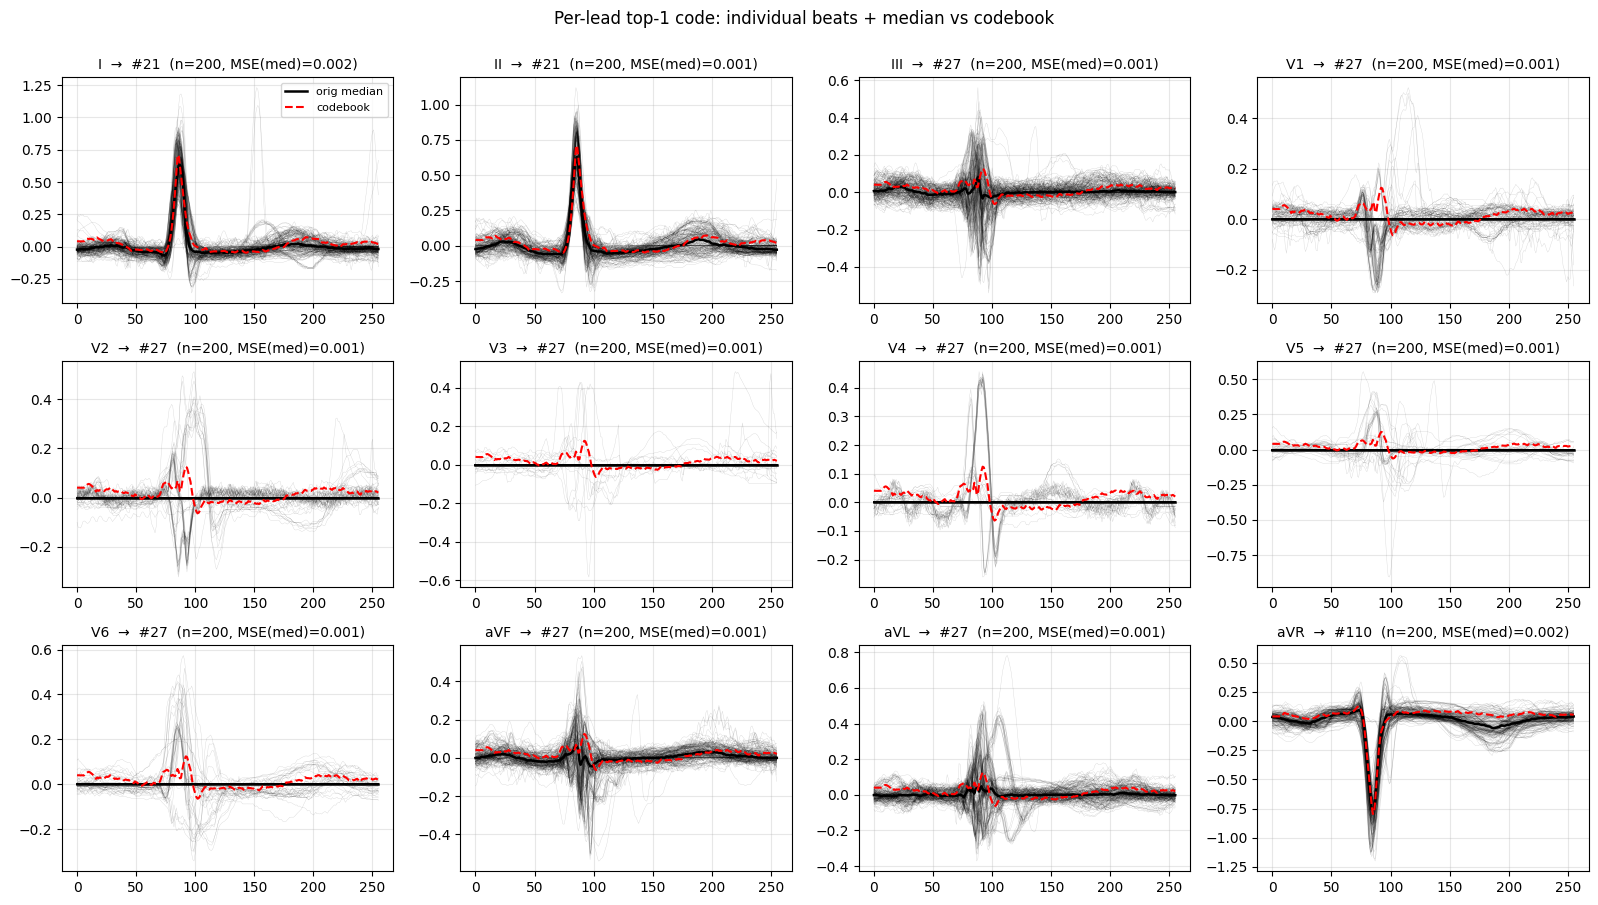

In [24]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, li in zip(axes.flat, range(NUM_LEADS)):
    B = np.stack(bank[li], axis=0) if bank[li] else np.zeros((1, beat_len))
    med = np.median(B, axis=0)
    for b in B:
        ax.plot(b, color='k', lw=0.3, alpha=0.15)
    ax.plot(med,     'k-',  lw=1.8, label='orig median')
    ax.plot(dec1[li], 'r--', lw=1.5, label='codebook')
    mse_med = ((med - dec1[li]) ** 2).mean()
    ax.set_title(f'{LEADS[li]}  →  #{int(top1[li])}  '
                 f'(n={len(B)}, MSE(med)={mse_med:.3f})', fontsize=10)
    ax.grid(alpha=0.3)
    if li == 0: ax.legend(fontsize=8, loc='upper right')
plt.suptitle('Per-lead top-1 code: individual beats + median vs codebook',
             y=1.00, fontsize=12)
plt.tight_layout(); plt.show()